Note: you may need to restart the kernel to use updated packages.


ValueError: Unknown format code 'f' for object of type 'str'

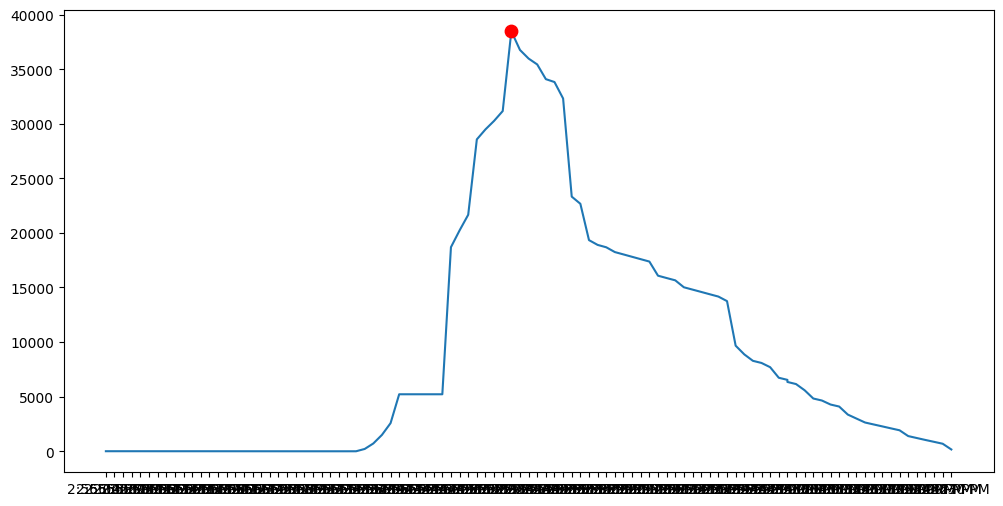

In [ ]:
%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Trimmed Aurora Telemetry Data.csv")

# Convert TIME column to datetime format
df['TIME'] = pd.to_datetime(df['TIME'], format='%I:%M:%S %p')

# Calculate elapsed time in seconds from the first timestamp
start_time = df['TIME'].iloc[0]
df['elapsed_seconds'] = (df['TIME'] - start_time).dt.total_seconds()

# Convert altitude to numeric (in case it has any string values)
df['Alt AGL (ft)'] = pd.to_numeric(df['Alt AGL (ft)'], errors='coerce')

print("First few rows with elapsed time:")
print(df[['TIME', 'elapsed_seconds', 'Alt AGL (ft)']].head())

apogee_idx = df['Alt AGL (ft)'].idxmax()   # row where altitude is max
apogee_time = df.loc[apogee_idx, 'elapsed_seconds']  # Use elapsed_seconds instead
apogee_alt  = df.loc[apogee_idx, 'Alt AGL (ft)']

plt.figure(figsize=(12, 6)) 
plt.plot(df['elapsed_seconds'], df['Alt AGL (ft)'], label='Altitude (ft)')

plt.scatter([apogee_time], [apogee_alt], color='red', s=80, zorder=5, label='Apogee')

plt.annotate(f'Apogee\n{apogee_alt:.1f} ft @ {apogee_time:.1f}s', 
             xy=(apogee_time, apogee_alt), 
             xytext=(apogee_time + 5, apogee_alt + 500), #offset label
             arrowprops=dict(facecolor='red', arrowstyle='->'),
             fontsize=10, color='black')

plt.title('Altitude vs Elapsed Time', fontsize=16, fontweight='bold')
plt.xlabel('Elapsed Time (seconds)', fontsize=12)
plt.ylabel('Alt AGL (ft)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()